<a href="https://colab.research.google.com/github/vivek-kothekar/Disease-Outbreak-Prediction-ML-TAE/blob/main/models/Logistic_Regression_TAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vivek Kothekar

Roll No: CS23110

Subject: Machine Learning

Topic: Disease Outbreak Prediction

Dataset: diabetes.csv

Model Used: Logistic Regression

___
AIM:

To implement the Logistic Regression algorithm on the diabetes dataset for predicting disease occurrence and classifying patients.
___

DATASET DESCRIPTION:

The diabetes dataset contains medical data of patients including features like glucose, blood pressure, BMI, insulin, and age. It is used to classify whether a person is diabetic or not.

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/ML/diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
# Target Distribution 0 == No ,1 == yes
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


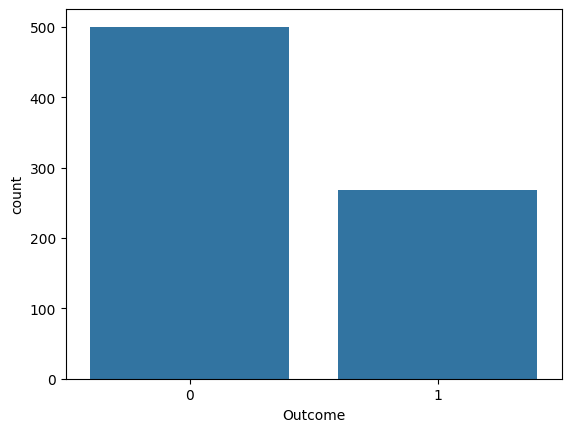

In [10]:
sns.countplot(x='Outcome', data=df)
plt.show()

In [11]:
# Feature and Target split x = input , y = output
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [12]:
# Train-Test Split , split in 80%,20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
print("Training shape:", X_train.shape)

Training shape: (614, 8)


In [14]:
print("Testing shape:", X_test.shape)

Testing shape: (154, 8)


In [15]:
# Feature Scaling , Converts values to same scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Model Implementation
lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [17]:
# Prediction , predit on test data
y_pred = lr_model.predict(X_test)

In [18]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy: {:.2f}%".format(accuracy * 100))

Logistic Regression Accuracy: 75.32%


In [19]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6491228070175439


In [20]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6727272727272727


In [21]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6607142857142857


[[79 20]
 [18 37]]


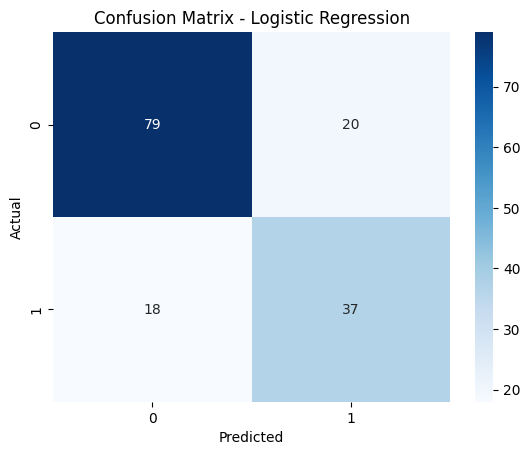

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



For 70%,30%

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
print("Training shape:", X_train.shape)

Training shape: (537, 8)


In [26]:
print("Testing shape:", X_test.shape)

Testing shape: (231, 8)


In [27]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Model Training
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [29]:
# Prediction
y_pred = model.predict(X_test)

In [30]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (70-30 split): {:.2f}%".format(accuracy * 100))

Accuracy (70-30 split): 73.59%


In [34]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6172839506172839


In [35]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.625


In [36]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6211180124223602


In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[120  31]
 [ 30  50]]


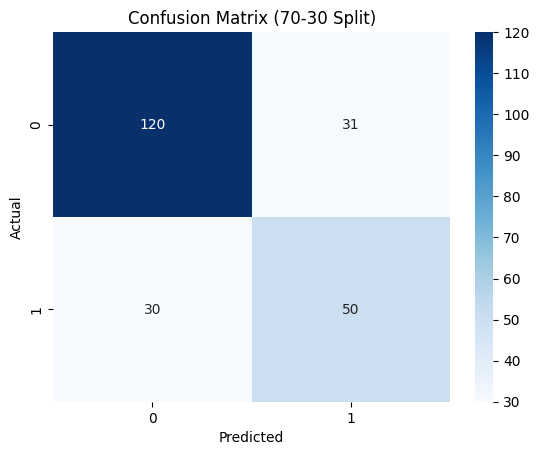

In [32]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (70-30 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231

